<a href="https://colab.research.google.com/github/jayanth-talasri/Solar-irradiance-forecasting-using-deep-Learning-model-LSTM-/blob/main/solar_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load datasets
summer = pd.read_csv("/content/Summer_2004-2006.csv")
rainy = pd.read_csv("/content/Raini_2004-2006.csv")
winter = pd.read_csv("/content/Winter_2004-2006.csv")

print("Summer Shape:", summer.shape)
print("Rainy Shape:", rainy.shape)
print("Winter Shape:", winter.shape)

Summer Shape: (52416, 11)
Rainy Shape: (53136, 11)
Winter Shape: (51983, 11)


In [2]:
print(summer.columns)
print(rainy.columns)
print(winter.columns)

Index(['Date Time', 'Time', 'Temperature', 'Relative Humidity', 'Pressure',
       'Wind speed', 'Wind direction', 'Rainfall', 'Snowfall', 'Snow depth',
       'Short-wave irradiation'],
      dtype='object')
Index(['Date Time', 'Time', 'Temperature', 'Relative Humidity', 'Pressure',
       'Wind speed', 'Wind direction', 'Rainfall', 'Snowfall', 'Snow depth',
       'Short-wave irradiation'],
      dtype='object')
Index(['Date Time', ' Time', 'Temperature', 'Relative Humidity', 'Pressure',
       'Wind speed', 'Wind direction', 'Rainfall', 'Snowfall', 'Snow depth',
       'Short-wave irradiation'],
      dtype='object')


In [4]:
summer.columns = summer.columns.str.strip()

print(summer.columns)

Index(['Date Time', 'Time', 'Temperature', 'Relative Humidity', 'Pressure',
       'Wind speed', 'Wind direction', 'Rainfall', 'Snowfall', 'Snow depth',
       'Short-wave irradiation'],
      dtype='object')


In [5]:
summer.isnull().sum()

,0
Date Time,0
Time,0
Temperature,0
Relative Humidity,0
Pressure,0
Wind speed,0
Wind direction,0
Rainfall,0
Snowfall,0
Snow depth,0


In [6]:
summer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52416 entries, 0 to 52415
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Date Time               52416 non-null  object 
 1   Time                    52416 non-null  object 
 2   Temperature             52416 non-null  float64
 3   Relative Humidity       52416 non-null  float64
 4   Pressure                52416 non-null  float64
 5   Wind speed              52416 non-null  float64
 6   Wind direction          52416 non-null  float64
 7   Rainfall                52416 non-null  float64
 8   Snowfall                52416 non-null  int64  
 9   Snow depth              52416 non-null  int64  
 10  Short-wave irradiation  52416 non-null  float64
dtypes: float64(7), int64(2), object(2)
memory usage: 4.4+ MB


In [7]:
summer["Datetime"] = pd.to_datetime(
    summer["Date Time"].astype(str) + " " + summer["Time"].astype(str)
)

print(summer[["Date Time", "Time", "Datetime"]].head())

  Date Time  Time            Datetime
0  3/1/2004  0:00 2004-03-01 00:00:00
1  3/1/2004  0:10 2004-03-01 00:10:00
2  3/1/2004  0:20 2004-03-01 00:20:00
3  3/1/2004  0:30 2004-03-01 00:30:00
4  3/1/2004  0:40 2004-03-01 00:40:00


In [8]:
summer = summer.sort_values("Datetime")

summer.head()

,Date Time,Time,Temperature,Relative Humidity,Pressure,Wind speed,Wind direction,Rainfall,Snowfall,Snow depth,Short-wave irradiation,Datetime
0,3/1/2004,0:00,293.41,80.33,1005.01,2.74,300.73,0.0,0,0,0.0,2004-03-01 00:00:00
1,3/1/2004,0:10,293.37,79.86,1005.16,2.76,302.82,0.0,0,0,0.0,2004-03-01 00:10:00
2,3/1/2004,0:20,293.32,79.39,1005.31,2.77,304.89,0.0,0,0,0.0,2004-03-01 00:20:00
3,3/1/2004,0:30,293.27,78.92,1005.47,2.80,306.92,0.0,0,0,0.0,2004-03-01 00:30:00
4,3/1/2004,0:40,293.44,77.53,1005.62,2.86,308.77,0.0,0,0,0.0,2004-03-01 00:40:00


In [9]:
summer.set_index("Datetime", inplace=True)

summer.head()

,Date Time,Time,Temperature,Relative Humidity,Pressure,Wind speed,Wind direction,Rainfall,Snowfall,Snow depth,Short-wave irradiation
Datetime,,,,,,,,,,,
2004-03-01 00:00:00,3/1/2004,0:00,293.41,80.33,1005.01,2.74,300.73,0.0,0,0,0.0
2004-03-01 00:10:00,3/1/2004,0:10,293.37,79.86,1005.16,2.76,302.82,0.0,0,0,0.0
2004-03-01 00:20:00,3/1/2004,0:20,293.32,79.39,1005.31,2.77,304.89,0.0,0,0,0.0
2004-03-01 00:30:00,3/1/2004,0:30,293.27,78.92,1005.47,2.80,306.92,0.0,0,0,0.0
2004-03-01 00:40:00,3/1/2004,0:40,293.44,77.53,1005.62,2.86,308.77,0.0,0,0,0.0


In [10]:
summer["Hour"] = summer.index.hour
summer["Day"] = summer.index.day
summer["Month"] = summer.index.month

summer.head()

,Date Time,Time,Temperature,Relative Humidity,Pressure,Wind speed,Wind direction,Rainfall,Snowfall,Snow depth,Short-wave irradiation,Hour,Day,Month
Datetime,,,,,,,,,,,,,,
2004-03-01 00:00:00,3/1/2004,0:00,293.41,80.33,1005.01,2.74,300.73,0.0,0,0,0.0,0,1,3
2004-03-01 00:10:00,3/1/2004,0:10,293.37,79.86,1005.16,2.76,302.82,0.0,0,0,0.0,0,1,3
2004-03-01 00:20:00,3/1/2004,0:20,293.32,79.39,1005.31,2.77,304.89,0.0,0,0,0.0,0,1,3
2004-03-01 00:30:00,3/1/2004,0:30,293.27,78.92,1005.47,2.80,306.92,0.0,0,0,0.0,0,1,3
2004-03-01 00:40:00,3/1/2004,0:40,293.44,77.53,1005.62,2.86,308.77,0.0,0,0,0.0,0,1,3


In [12]:
features = [
    "Temperature",
    "Relative Humidity",
    "Pressure",
    "Wind speed",
    "Wind direction",
    "Rainfall",
    "Snowfall",
    "Snow depth",
    "Hour",
    "Day",
    "Month"
]

In [13]:
target = "Short-wave irradiation"

In [14]:
X = summer[features]
y = summer[target]

print(X.head())
print(y.head())

                     Temperature  Relative Humidity  Pressure  Wind speed  \
Datetime                                                                    
2004-03-01 00:00:00       293.41              80.33   1005.01        2.74   
2004-03-01 00:10:00       293.37              79.86   1005.16        2.76   
2004-03-01 00:20:00       293.32              79.39   1005.31        2.77   
2004-03-01 00:30:00       293.27              78.92   1005.47        2.80   
2004-03-01 00:40:00       293.44              77.53   1005.62        2.86   

                     Wind direction  Rainfall  Snowfall  Snow depth  Hour  \
Datetime                                                                    
2004-03-01 00:00:00          300.73       0.0         0           0     0   
2004-03-01 00:10:00          302.82       0.0         0           0     0   
2004-03-01 00:20:00          304.89       0.0         0           0     0   
2004-03-01 00:30:00          306.92       0.0         0           0     0  

In [16]:
from sklearn.preprocessing import MinMaxScaler

In [18]:
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

X_scaled = feature_scaler.fit_transform(X)

y_scaled = target_scaler.fit_transform(y.values.reshape(-1, 1))

In [19]:
print("X_scaled shape:", X_scaled.shape)
print("y_scaled shape:", y_scaled.shape)

X_scaled shape: (52416, 11)
y_scaled shape: (52416, 1)


In [20]:
X_scaled = pd.DataFrame(X_scaled, columns=features, index=summer.index)

y_scaled = pd.DataFrame(y_scaled, columns=[target], index=summer.index)

X_scaled.head()

,Temperature,Relative Humidity,Pressure,Wind speed,Wind direction,Rainfall,Snowfall,Snow depth,Hour,Day,Month
Datetime,,,,,,,,,,,
2004-03-01 00:00:00,0.088855,0.802614,0.659333,0.181757,0.835845,0.0,0.0,0.0,0.0,0.0,0.0
2004-03-01 00:10:00,0.087323,0.797029,0.664656,0.183099,0.841655,0.0,0.0,0.0,0.0,0.0,0.0
2004-03-01 00:20:00,0.085408,0.791444,0.669979,0.183769,0.847409,0.0,0.0,0.0,0.0,0.0,0.0
2004-03-01 00:30:00,0.083493,0.785859,0.675656,0.185781,0.853052,0.0,0.0,0.0,0.0,0.0,0.0
2004-03-01 00:40:00,0.090004,0.769340,0.680979,0.189805,0.858195,0.0,0.0,0.0,0.0,0.0,0.0


In [21]:
sequence_length = 24

In [22]:
def create_sequences(X, y, sequence_length):

    X_sequences = []
    y_sequences = []

    for i in range(sequence_length, len(X)):

        X_sequences.append(
            X.iloc[i-sequence_length:i].values
        )

        y_sequences.append(
            y.iloc[i].values
        )

    return np.array(X_sequences), np.array(y_sequences)

In [23]:
X_seq, y_seq = create_sequences(
    X_scaled,
    y_scaled,
    sequence_length
)

In [24]:
print("X_seq shape:", X_seq.shape)
print("y_seq shape:", y_seq.shape)

X_seq shape: (52392, 24, 11)
y_seq shape: (52392, 1)


In [26]:
train_size = int(len(X_seq) * 0.8)

X_train = X_seq[:train_size]
X_test = X_seq[train_size:]

y_train = y_seq[:train_size]
y_test = y_seq[train_size:]

In [27]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (41913, 24, 11)
X_test shape: (10479, 24, 11)
y_train shape: (41913, 1)
y_test shape: (10479, 1)


Completed LSTM sequence generation

In [28]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [29]:
model = Sequential()

# First LSTM Layer
model.add(
    LSTM(
        units=64,
        return_sequences=True,
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)

model.add(Dropout(0.2))

# Second LSTM Layer
model.add(
    LSTM(
        units=64,
        return_sequences=False
    )
)

model.add(Dropout(0.2))

# Dense Layers
model.add(Dense(32, activation='relu'))

# Output Layer
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [31]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae']
)

In [32]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,593 (213.25 KB)

 Trainable params: 54,593 (213.25 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 35s 29ms/step - loss: 8.8490e-04 - mae: 0.0172 - val_loss: 0.0020 - val_mae: 0.0209
Epoch 2/20
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 36s 31ms/step - loss: 8.2111e-04 - mae: 0.0168 - val_loss: 0.0018 - val_mae: 0.0235
Epoch 3/20
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 40s 30ms/step - loss: 8.0195e-04 - mae: 0.0163 - val_loss: 0.0015 - val_mae: 0.0205
Epoch 4/20
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 35s 30ms/step - loss: 7.3192e-04 - mae: 0.0157 - val_loss: 0.0013 - val_mae: 0.0186
Epoch 5/20
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 34s 29ms/step - loss: 7.4620e-04 - mae: 0.0159 - val_loss: 0.0019 - val_mae: 0.0220
Epoch 6/20
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 43s 30ms/step - loss: 6.8624e-04 - mae: 0.0154 - val_loss: 0.0017 - val_mae: 0.0219
Epoch 7/20
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 34s 29ms/step - loss: 6.4907e-04 - mae: 0.0149 - val_loss: 0.0012 - val_mae: 0.0174
Epoch 8/20
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 42s 30ms/step - loss: 6.2070e-04 - mae: 0.0146 - val_loss: 0.0016 - val_mae:

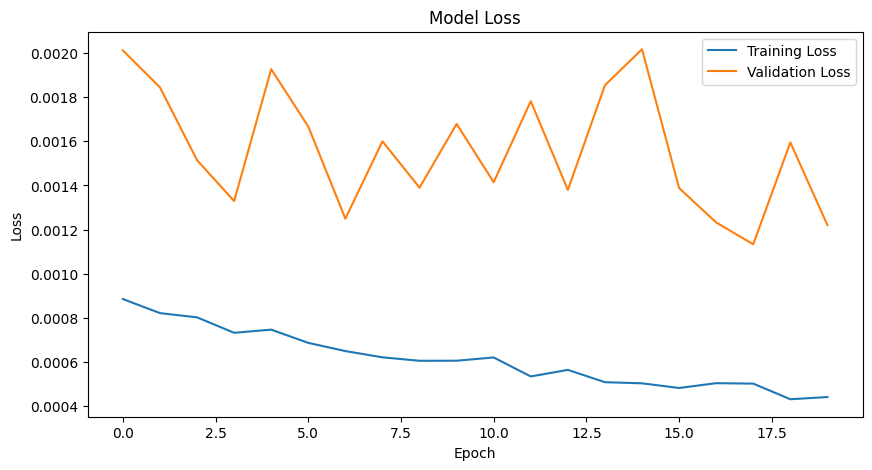

In [35]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [36]:
model.save("summer_lstm_model.h5")